# ------ Regularize linear regression model using L1 & L2 ------


### HOUSE SALE PRICEING PREDICTION

![title](house-prices-scaled.jpg)

Table of contents of the work:

**PREPROCESSING**

- Importing Libraries & Data.
- Combine Train and Test Sets.
- VISUALIZATION.
- **Cleaning the data.**
-  1- Fill Categorical Missing Values.
-  2- Fill Numeric Missing Values.
- **Feature transformations.**
-  1- Log Transform for Skewed Features.
-  2- Cosine Transform for Cyclical Features.
- Encode Categoricals.
- Scaling.
- Target transformation.
- Split Data.

**Model selection**
-  1- My LinearRegression Model.
-  2- My Poly Model.
-  3- My Ridge Model (L2).
-  4- My Lasso Model (L1).
-  5- sklearn.linear_model.LinearRegression.
-  6- sklearn.preprocessing.PolynomialFeatures
-  7- sklearn.linear_model.Ridge.
-  8- sklearn.linear_model.Lasso.
- Prediction
- Submission

In [1]:
# Importing the required libraries

import numpy as np
import pandas as pd 
import scipy.stats 
from scipy.stats import norm
from scipy.stats import skew, norm
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style('darkgrid')

from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.neighbors import KNeighborsRegressor

from sklearn.linear_model import Lasso, Ridge, LinearRegression


In [2]:
# Reading the data file

train0 = pd.read_csv('train.csv')
test0 = pd.read_csv('test.csv')
sample_submission = pd.read_csv('result-with-best.csv')

In [4]:
# Read All columns and Rows

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 90)

In [5]:
train0

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2003,2003,Gable,CompShg,VinylSd,VinylSd,BrkFace,196.0,Gd,TA,PConc,Gd,TA,No,GLQ,706,Unf,0,150,856,GasA,Ex,Y,SBrkr,856,854,0,1710,1,0,2,1,3,1,Gd,8,Typ,0,NaN,Attchd,2003.0,RFn,2,548,TA,TA,Y,0,61,0,0,0,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,FR2,Gtl,Veenker,Feedr,Norm,1Fam,1Story,6,8,1976,1976,Gable,CompShg,MetalSd,MetalSd,None,0.0,TA,TA,CBlock,Gd,TA,Gd,ALQ,978,Unf,0,284,1262,GasA,Ex,Y,SBrkr,1262,0,0,1262,0,1,2,0,3,1,TA,6,Typ,1,TA,Attchd,1976.0,RFn,2,460,TA,TA,Y,298,0,0,0,0,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2001,2002,Gable,CompShg,VinylSd,VinylSd,BrkFace,162.0,Gd,TA,PConc,Gd,TA,Mn,GLQ,486,Unf,0,434,920,GasA,Ex,Y,SBrkr,920,866,0,1786,1,0,2,1,3,1,Gd,6,Typ,1,TA,Attchd,2001.0,RFn,2,608,TA,TA,Y,0,42,0,0,0,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,Crawfor,Norm,Norm,1Fam,2Story,7,5,1915,1970,Gable,CompShg,Wd Sdng,Wd Shng,None,0.0,TA,TA,BrkTil,TA,Gd,No,ALQ,216,Unf,0,540,756,GasA,Gd,Y,SBrkr,961,756,0,1717,1,0,1,0,3,1,Gd,7,Typ,1,Gd,Detchd,1998.0,Unf,3,642,TA,TA,Y,0,35,272,0,0,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,FR2,Gtl,NoRidge,Norm,Norm,1Fam,2Story,8,5,2000,2000,Gable,CompShg,VinylSd,VinylSd,BrkFace,350.0,Gd,TA,PConc,Gd,TA,Av,GLQ,655,Unf,0,490,1145,GasA,Ex,Y,SBrkr,1145,1053,0,2198,1,0,2,1,4,1,Gd,9,Typ,1,TA,Attchd,2000.0,RFn,3,836,TA,TA,Y,192,84,0,0,0,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1455,1456,60,RL,62.0,7917,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,Gilbert,Norm,Norm,1Fam,2Story,6,5,1999,2000,Gable,CompShg,VinylSd,VinylSd,None,0.0,TA,TA,PConc,Gd,TA,No,Unf,0,Unf,0,953,953,GasA,Ex,Y,SBrkr,953,694,0,1647,0,0,2,1,3,1,TA,7,Typ,1,TA,Attchd,1999.0,RFn,2,460,TA,TA,Y,0,40,0,0,0,0,NaN,NaN,NaN,0,8,2007,WD,Normal,175000
1456,1457,20,RL,85.0,13175,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,NWAmes,Norm,Norm,1Fam,1Story,6,6,1978,1988,Gable,CompShg,Plywood,Plywood,Stone,119.0,TA,TA,CBlock,Gd,TA,No,ALQ,790,Rec,163,589,1542,GasA,TA,Y,SBrkr,2073,0,0,2073,1,0,2,0,3,1,TA,7,Min1,2,TA,Attchd,1978.0,Unf,2,500,TA,TA,Y,349,0,0,0,0,0,NaN,MnPrv,NaN,0,2,2010,WD,Normal,210000
1457,1458,70,RL,66.0,9042,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,Crawfor,Norm,Norm,1Fam,2Story,7,9,1941,2006,Gable,CompShg,CemntBd,CmentBd,None,0.0,Ex,Gd,Stone,TA,Gd,No,GLQ,275,Unf,0,877,1152,GasA,Ex,Y,SBrkr,1188,1152,0,2340,0,0,2,0,4,1,Gd,9,Typ,2,Gd,Attchd,1941.0,RFn,1,252,TA,TA,Y,0,60,0,0,0,0,NaN,GdPrv,Shed,2500,5,2010,WD,Normal,266500
1458,1459,20,RL,68.0,9717,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,NAmes,Norm,Norm,1Fam,1Story,5,6,1950,1996,Hip,CompShg,MetalSd,MetalSd,None,0.0,TA,TA,CBlock,TA,TA,Mn,GLQ,49,Rec,1029,0,1078,Gas

In [5]:
test0

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition
0,1461,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,AllPub,...,120,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal
1,1462,20,RL,81.0,14267,Pave,NaN,IR1,Lvl,AllPub,...,0,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal
2,1463,60,RL,74.0,13830,Pave,NaN,IR1,Lvl,AllPub,...,0,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal
3,1464,60,RL,78.0,9978,Pave,NaN,IR1,Lvl,AllPub,...,0,0,NaN,NaN,NaN,0,6,2010,WD,Normal
4,1465,120,RL,43.0,5005,Pave,NaN,IR1,HLS,AllPub,...,144,0,NaN,NaN,NaN,0,1,2010,WD,Normal
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1454,2915,160,RM,21.0,1936,Pave,NaN,Reg,Lvl,AllPub,...,0,0,NaN,NaN,NaN,0,6,2006,WD,Normal
1455,2916,160,RM,21.0,1894,Pave,NaN,Reg,Lvl,AllPub,...,0,0,NaN,NaN,NaN,0,4,2006,WD,Abnorml
1456,2917,20,RL,160.0,20000,Pave,NaN,Reg,Lvl,AllPub,...,0,0,NaN,NaN,NaN,0,9,2006,WD,Abnorml
1457,2918,85,RL,62.0,10441,Pave,NaN,Reg,Lvl,AllPub,...,0,0,NaN,MnPrv,Shed,700,7,2006,WD,Normal


In [6]:
sample_submission

,Id,SalePrice
0,1461,105000.0
1,1462,172000.0
2,1463,189900.0
3,1464,195500.0
4,1465,191500.0
...,...,...
1454,2915,90500.0
1455,2916,71000.0
1456,2917,131000.0
1457,2918,132000.0


# Combine Train and Test Sets

In [7]:
target = train0['SalePrice']
test_ids = test0['Id']

train1 = train0.drop(['SalePrice','Id'], axis=1)
test1 = test0.drop('Id', axis=1)

data1 = pd.concat([train1, test1], axis=0).reset_index(drop=True)
data1.columns = data1.columns.str.replace(' ', '')                      # Replacing the white spaces in columns' names
data1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2919 entries, 0 to 2918
Data columns (total 79 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   MSSubClass     2919 non-null   int64  
 1   MSZoning       2915 non-null   object 
 2   LotFrontage    2433 non-null   float64
 3   LotArea        2919 non-null   int64  
 4   Street         2919 non-null   object 
 5   Alley          198 non-null    object 
 6   LotShape       2919 non-null   object 
 7   LandContour    2919 non-null   object 
 8   Utilities      2917 non-null   object 
 9   LotConfig      2919 non-null   object 
 10  LandSlope      2919 non-null   object 
 11  Neighborhood   2919 non-null   object 
 12  Condition1     2919 non-null   object 
 13  Condition2     2919 non-null   object 
 14  BldgType       2919 non-null   object 
 15  HouseStyle     2919 non-null   object 
 16  OverallQual    2919 non-null   int64  
 17  OverallCond    2919 non-null   int64  
 18  YearBuil

In [8]:
target

0       208500
1       181500
2       223500
3       140000
4       250000
         ...  
1455    175000
1456    210000
1457    266500
1458    142125
1459    147500
Name: SalePrice, Length: 1460, dtype: int64

In [9]:
data1

,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,...,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition
0,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,...,0,0,NaN,NaN,NaN,0,2,2008,WD,Normal
1,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,FR2,...,0,0,NaN,NaN,NaN,0,5,2007,WD,Normal
2,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,Inside,...,0,0,NaN,NaN,NaN,0,9,2008,WD,Normal
3,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,Corner,...,0,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml
4,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,FR2,...,0,0,NaN,NaN,NaN,0,12,2008,WD,Normal
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2914,160,RM,21.0,1936,Pave,NaN,Reg,Lvl,AllPub,Inside,...,0,0,NaN,NaN,NaN,0,6,2006,WD,Normal
2915,160,RM,21.0,1894,Pave,NaN,Reg,Lvl,AllPub,Inside,...,0,0,NaN,NaN,NaN,0,4,2006,WD,Abnorml
2916,20,RL,160.0,20000,Pave,NaN,Reg,Lvl,AllPub,Inside,...,0,0,NaN,NaN,NaN,0,9,2006,WD,Abnorml
2917,85,RL,62.0,10441,Pave,NaN,Reg,Lvl,AllPub,Inside,...,0,0,NaN,MnPrv,Shed,700,7,2006,WD,Normal


### VISUALIZATION

Before working with any kind of data it is important to understand them. The correlation matrix is the best way to see all the numerical correlation between features. Let's see which are the feature that correlate most with our target variable.

C:\Users\Hp\AppData\Local\Temp\ipykernel_13664\1583150738.py:4: FutureWarning: The default value of numeric_only in DataFrame.corr is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  mat = train0.corr('pearson')


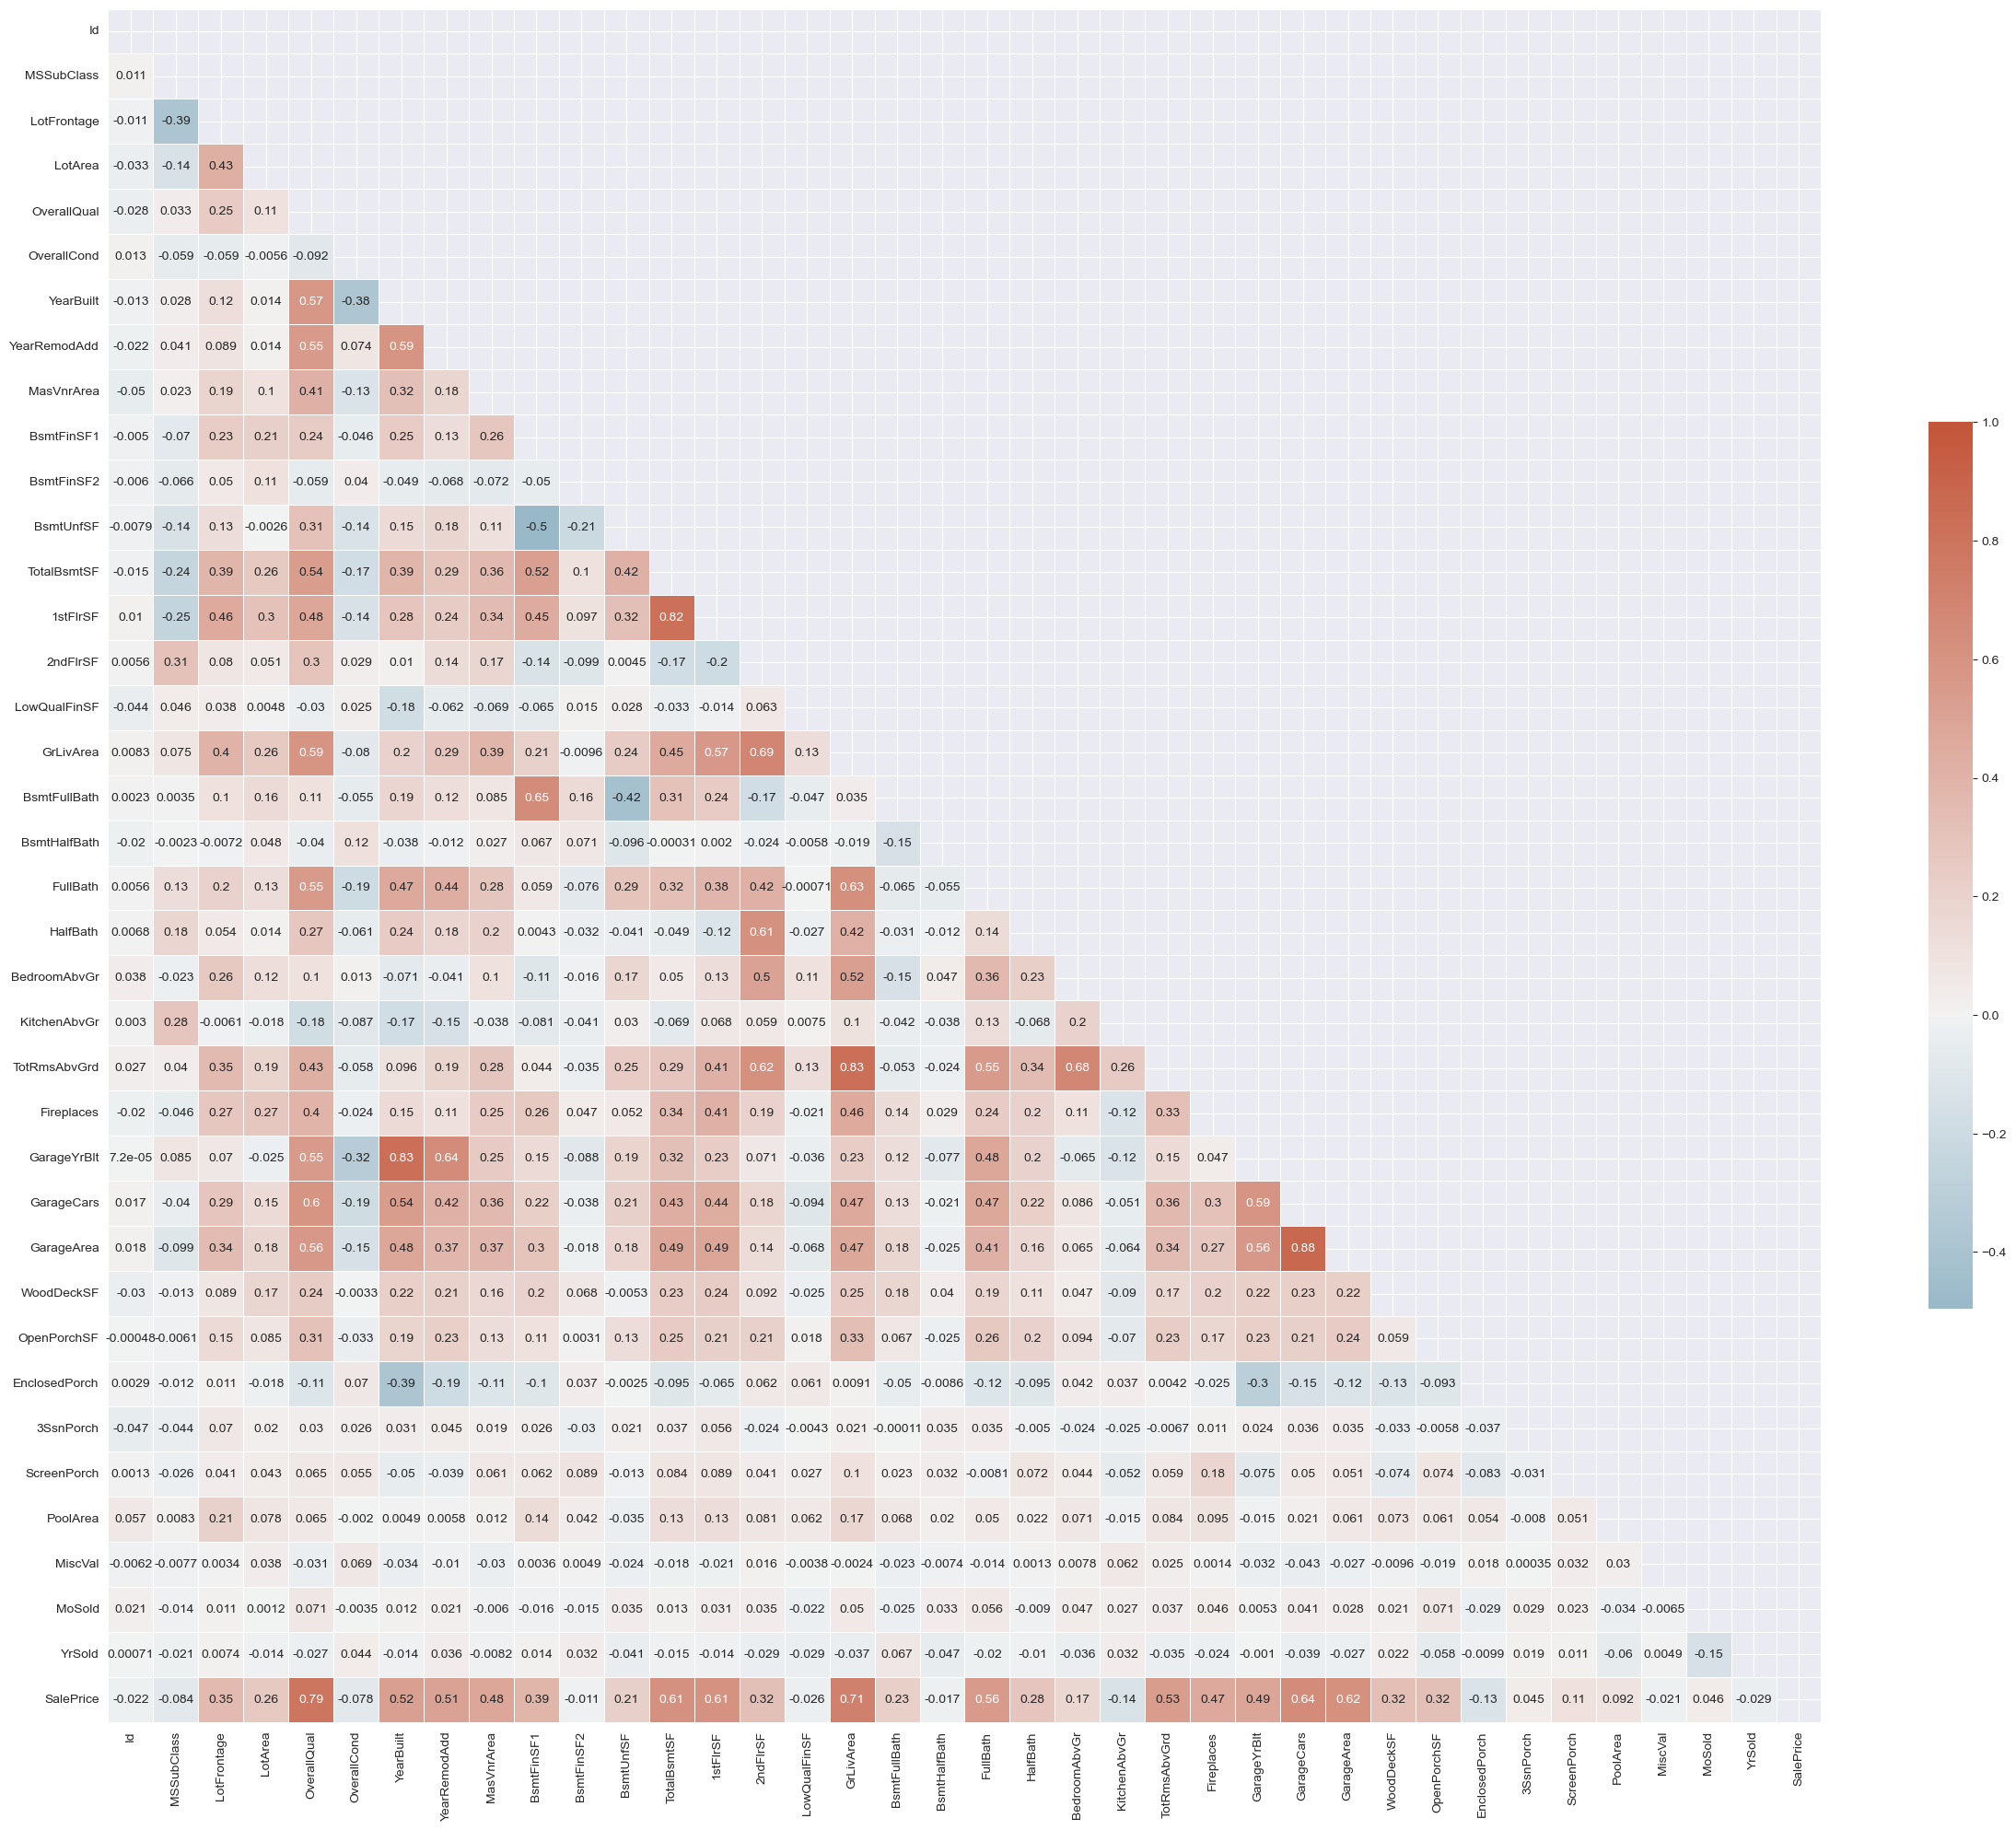

In [10]:
# Correlation Matrix

f, ax = plt.subplots(figsize=(30, 25))
mat = train0.corr('pearson')
mask = np.triu(np.ones_like(mat, dtype=bool))
cmap = sns.diverging_palette(230, 20, as_cmap=True)
sns.heatmap(mat, mask=mask, cmap=cmap, vmax=1, center=0, annot = True,
            square=True, linewidths=.5, cbar_kws={"shrink": .5})
plt.show()

Now that we know which features correlates most with our target variable we can investigate them more in depth.

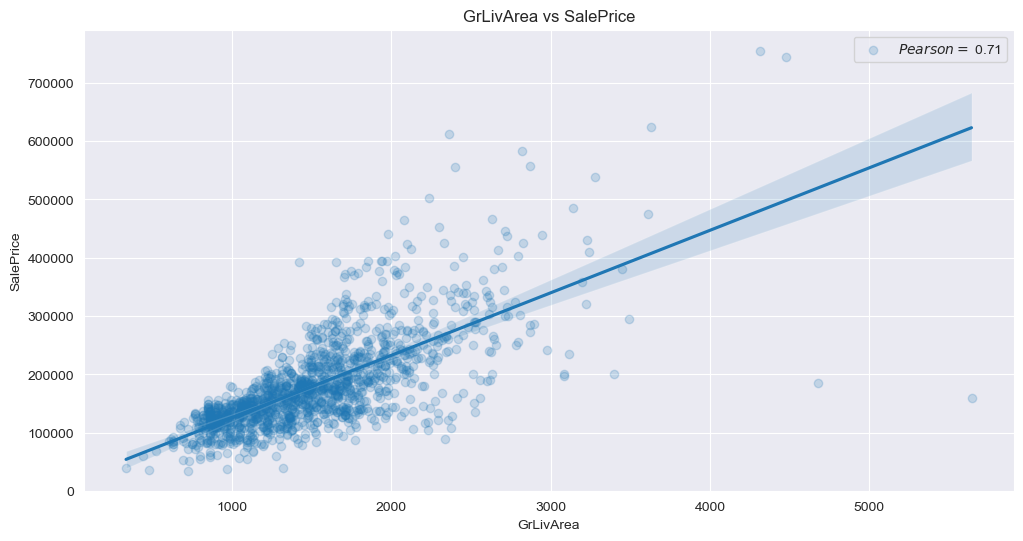

In [11]:
# GrLivArea vs SalePrice [corr = 0.71]

Pearson_GrLiv = 0.71
plt.figure(figsize = (12,6))
sns.regplot(data=train0, x = 'GrLivArea', y='SalePrice', scatter_kws={'alpha':0.2})
plt.title('GrLivArea vs SalePrice', fontsize = 12)
plt.legend(['$Pearson=$ {:.2f}'.format(Pearson_GrLiv)], loc = 'best')
plt.show()

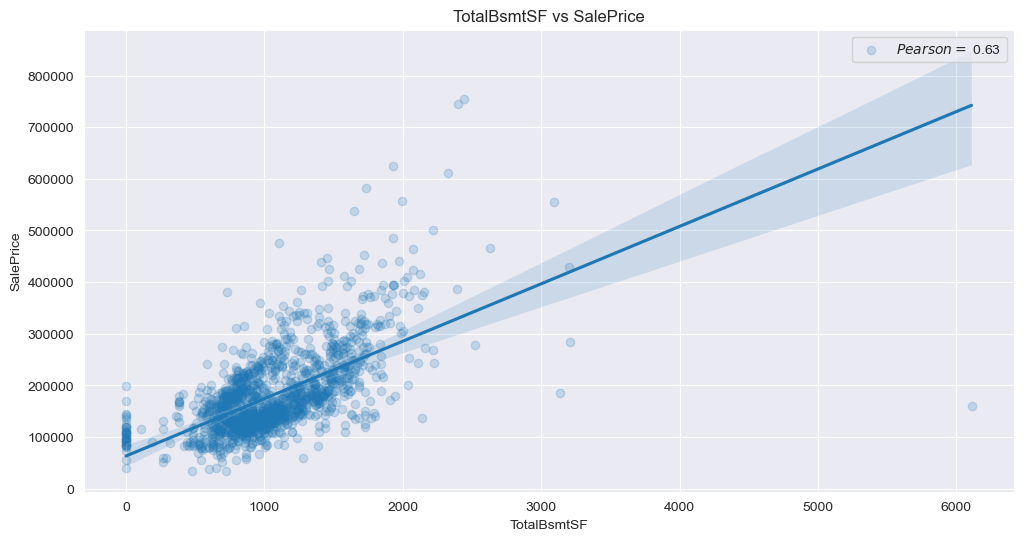

In [12]:
Pearson_TBSF = 0.63
plt.figure(figsize = (12,6))
sns.regplot(data=train0, x = 'TotalBsmtSF', y='SalePrice', scatter_kws={'alpha':0.2})
plt.title('TotalBsmtSF vs SalePrice', fontsize = 12)
plt.legend(['$Pearson=$ {:.2f}'.format(Pearson_TBSF)], loc = 'best')
plt.show()

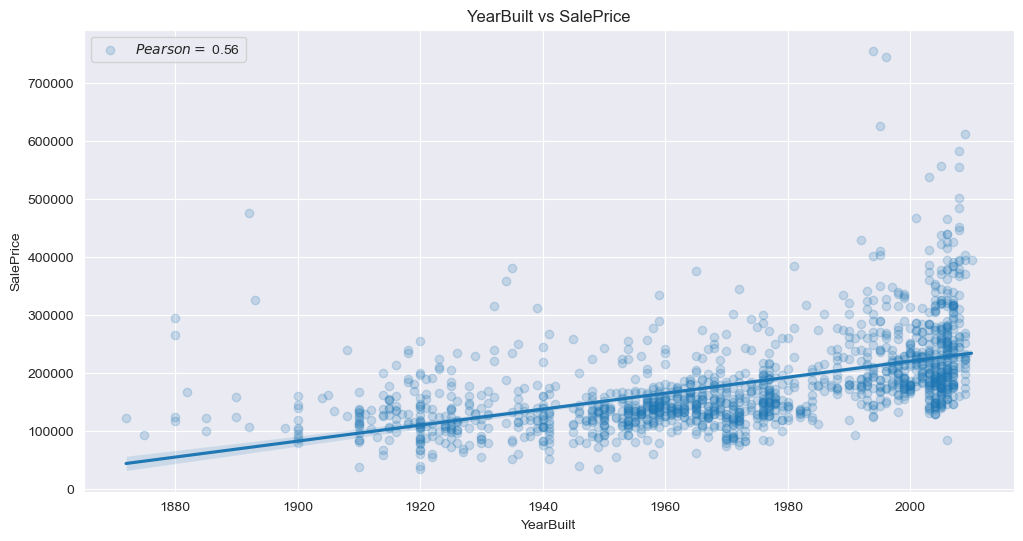

In [13]:
# YearBuilt vs SalePrice

Pearson_YrBlt = 0.56
plt.figure(figsize = (12,6))
sns.regplot(data=train0, x = 'YearBuilt', y='SalePrice', scatter_kws={'alpha':0.2})
plt.title('YearBuilt vs SalePrice', fontsize = 12)
plt.legend(['$Pearson=$ {:.2f}'.format(Pearson_YrBlt)], loc = 'best')
plt.show()

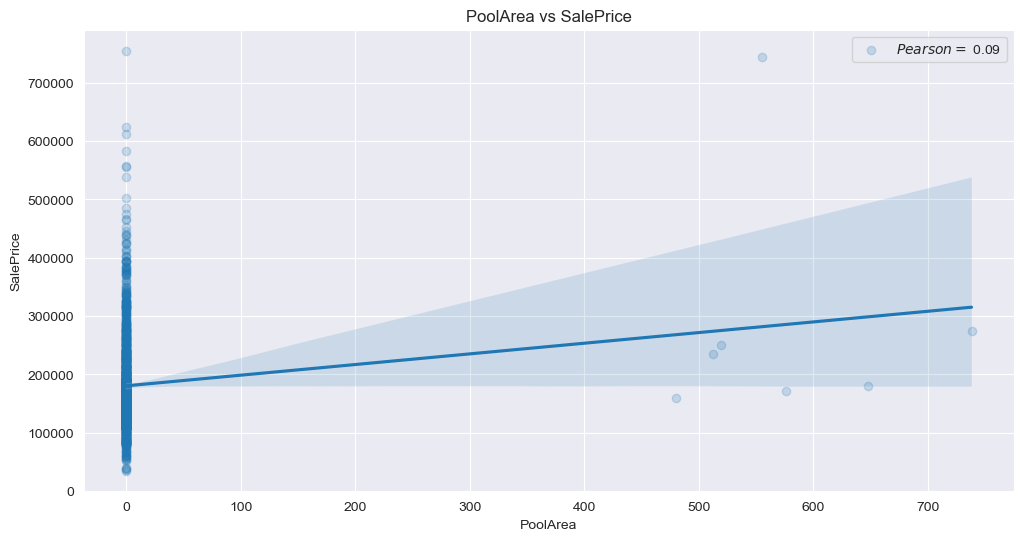

In [14]:
# PoolArea vs SalePrice [corr = 0.092]

Pearson_PoolArea = 0.092
plt.figure(figsize = (12,6))
sns.regplot(data=train0, x = 'PoolArea', y='SalePrice', scatter_kws={'alpha':0.2})
plt.title('PoolArea vs SalePrice', fontsize = 12)
plt.legend(['$Pearson=$ {:.2f}'.format(Pearson_PoolArea)], loc = 'best')
plt.show()

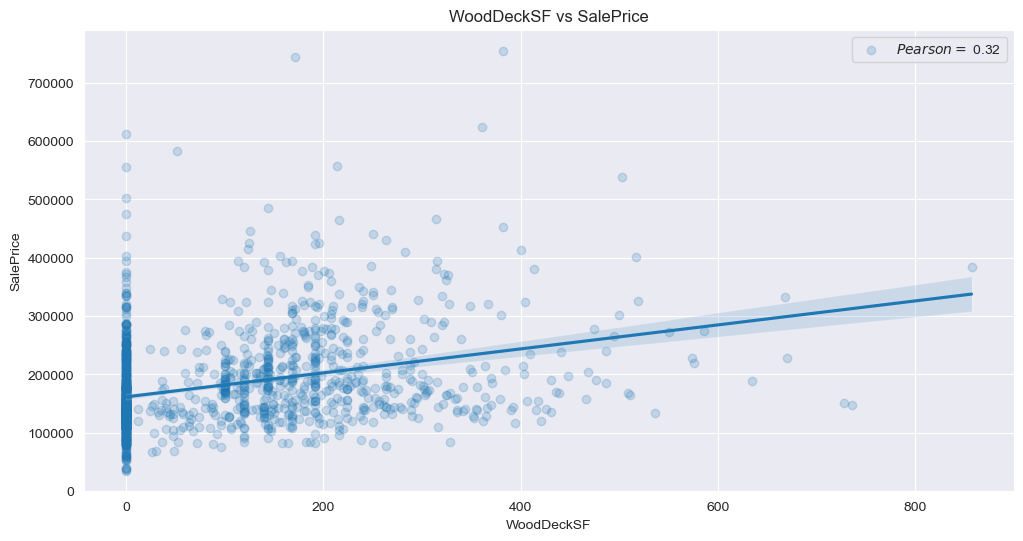

In [15]:
# PoolArea vs SalePrice [corr = 0.092]

Pearson_WoodDeckSF = 0.32
plt.figure(figsize = (12,6))
sns.regplot(data=train0, x = 'WoodDeckSF', y='SalePrice', scatter_kws={'alpha':0.2})
plt.title('WoodDeckSF vs SalePrice', fontsize = 12)
plt.legend(['$Pearson=$ {:.2f}'.format(Pearson_WoodDeckSF)], loc = 'best')
plt.show()

# Cleaning the data

In [16]:
data2 = data1.copy()

<Axes: >

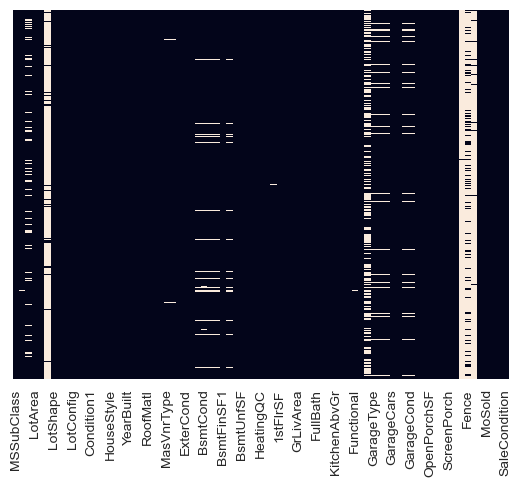

In [17]:
sns.heatmap(data2.isna(), yticklabels=False, cbar=False)

### Ensure Proper Data Types
التاكد من نوع البيانات هل هي بيانات عددية او بيانات تصنيف "يمكن ان تكون البيانات للتصنيف حتى لو كانت قيمها عبارة عن ارقام" لذلك يجب تعديلها واعتبارها من نوع بيانات التصنيف
لعمل ذلك نقوم بتحويل نوع البيانات من انتجر او فلوت الى سترنج

In [18]:
# Convert the data type from int or float to string for the  categorical numeric columns:

data2['MSSubClass'] = data2['MSSubClass'].astype(str)

### Fill Categorical Missing Values

In [19]:
# To show the categorical columns that have missing values

data2.select_dtypes('object').loc[: ,data2.isna().sum() > 0].columns

Index(['MSZoning', 'Alley', 'Utilities', 'Exterior1st', 'Exterior2nd',
       'MasVnrType', 'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1',
       'BsmtFinType2', 'Electrical', 'KitchenQual', 'Functional',
       'FireplaceQu', 'GarageType', 'GarageFinish', 'GarageQual', 'GarageCond',
       'PoolQC', 'Fence', 'MiscFeature', 'SaleType'],
      dtype='object')

In [20]:
# Filling Categorical columns that have Missing Values:

# Impute using a constant value "for coulmns that have (NA) no values" 
for column in[
    'Alley',
    'BsmtQual',
    'BsmtCond',
    'BsmtExposure',
    'BsmtFinType1',
    'BsmtFinType2',
    'FireplaceQu',
    'GarageType',
    'GarageFinish',
    'GarageQual',
    'GarageCond',
    'PoolQC',
    'Fence',
    'MiscFeature'
]:
    data2[column] = data2[column].fillna("None")

# Impute using the column mode
for column in[
    'MSZoning',
    'Utilities',
    'Exterior1st',
    'Exterior2nd',
    'MasVnrType',
    'Electrical',
    'KitchenQual',
    'Functional',
    'SaleType'
]:
    data2[column] = data2[column].fillna(data2[column].mode()[0])

In [21]:
# Check if any categorical coulumns have missing values

data2.select_dtypes('object').isna().sum().sum()

0

### Fill Numeric Missing Values

In [22]:
data3 = data2.copy()

## عمل اقتران لتعبئة القيم العددية المفقودة بناءاً على القيم المجاورة لها

In [27]:
# Function to fill Numerical Missing Values

def knn_impute(df, na_target):
    df = df.copy()

    numeric_df = df.select_dtypes(np.number)                                     # choice just the numeric columns
    non_na_columns = numeric_df.loc[: ,numeric_df.isna().sum() == 0].columns

    y_train = numeric_df.loc[numeric_df[na_target].isna() == False, na_target]
    x_train = numeric_df.loc[numeric_df[na_target].isna() == False, non_na_columns]
    x_test = numeric_df.loc[numeric_df[na_target].isna() == True, non_na_columns]

    knn = KNeighborsRegressor()
    knn.fit(x_train, y_train)

    y_pred = knn.predict(x_test)

    df.loc[df[na_target].isna() == True, na_target] = y_pred

    return df

In [28]:
# To show the Numerical columns that have missing values

data3.columns[data3.isna().sum() > 0]

Index(['LotFrontage', 'MasVnrArea', 'BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF',
       'TotalBsmtSF', 'BsmtFullBath', 'BsmtHalfBath', 'GarageYrBlt',
       'GarageCars', 'GarageArea'],
      dtype='object')

In [29]:
# Filling Numerical columns that have Missing Values:

for column in[
    'LotFrontage',
    'MasVnrArea', 
    'BsmtFinSF1',
    'BsmtFinSF2',
    'BsmtUnfSF',
    'TotalBsmtSF', 
    'BsmtFullBath',
    'BsmtHalfBath',
    'GarageYrBlt',
    'GarageCars', 
    'GarageArea'
]:
    data3 = knn_impute(data3, column)

In [30]:
# Check if any Numerical coulumns have missing values

data3.select_dtypes(np.number).isna().sum().sum()

0

In [31]:
# Check if any coulumns have missing values for All data set

data3.isna().sum().sum()

0

<AxesSubplot:>

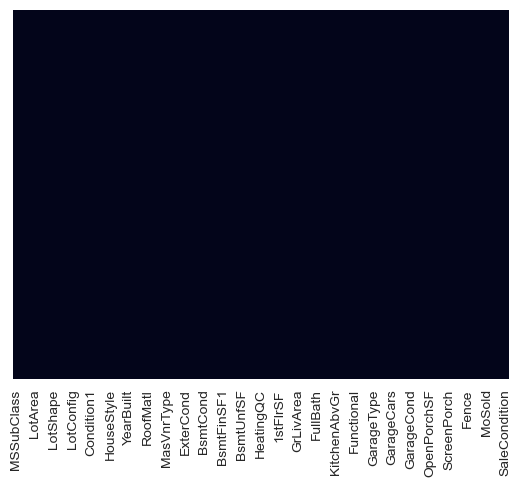

In [32]:
sns.heatmap(data3.isna(), yticklabels=False, cbar=False)

# Feature transformations

In [33]:
data4 = data3.copy()

In [34]:
data4.select_dtypes(np.number)

,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,BsmtFinSF2,BsmtUnfSF,...,GarageArea,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold
0,65.0,8450,7,5,2003,2003,196.0,706.0,0.0,150.0,...,548.0,0,61,0,0,0,0,0,2,2008
1,80.0,9600,6,8,1976,1976,0.0,978.0,0.0,284.0,...,460.0,298,0,0,0,0,0,0,5,2007
2,68.0,11250,7,5,2001,2002,162.0,486.0,0.0,434.0,...,608.0,0,42,0,0,0,0,0,9,2008
3,60.0,9550,7,5,1915,1970,0.0,216.0,0.0,540.0,...,642.0,0,35,272,0,0,0,0,2,2006
4,84.0,14260,8,5,2000,2000,350.0,655.0,0.0,490.0,...,836.0,192,84,0,0,0,0,0,12,2008
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2914,21.0,1936,4,7,1970,1970,0.0,0.0,0.0,546.0,...,0.0,0,0,0,0,0,0,0,6,2006
2915,21.0,1894,4,5,1970,1970,0.0,252.0,0.0,294.0,...,286.0,0,24,0,0,0,0,0,4,2006
2916,160.0,20000,5,7,1960,1996,0.0,1224.0,0.0,0.0,...,576.0,474,0,0,0,0,0,0,9,2006
2917,62.0,10441,5,5,1992,1992,0.0,337.0,0.0,575.0,...,0.0,80,32,0,0,0,0,700,7,2006


## Log Transform for Skewed Features --- حساب الانحراف  

In [35]:
skew_df = pd.DataFrame(data4.select_dtypes(np.number).columns, columns=['Feature'])
skew_df['Skew'] = skew_df['Feature'].apply(lambda feature: scipy.stats.skew(data4[feature]))
skew_df['ِAbsolute Skew'] = skew_df['Skew'].apply(abs)
skew_df['Skewed'] = skew_df['ِAbsolute Skew'].apply(lambda x: True if x >= 0.5 else False)
skew_df

,Feature,Skew,ِAbsolute Skew,Skewed
0,LotFrontage,1.340751,1.340751,True
1,LotArea,12.822431,12.822431,True
2,OverallQual,0.197110,0.197110,False
3,OverallCond,0.570312,0.570312,True
4,YearBuilt,-0.599806,0.599806,True
5,YearRemodAdd,-0.451020,0.451020,False
6,MasVnrArea,2.603682,2.603682,True
7,BsmtFinSF1,1.425516,1.425516,True
8,BsmtFinSF2,4.146111,4.146111,True
9,BsmtUnfSF,0.919322,0.919322,True


In [36]:
# The columns that have a skew value

skew_df.query("Skewed == True")['Feature'].values

array(['LotFrontage', 'LotArea', 'OverallCond', 'YearBuilt', 'MasVnrArea',
       'BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', '1stFlrSF',
       '2ndFlrSF', 'LowQualFinSF', 'GrLivArea', 'BsmtFullBath',
       'BsmtHalfBath', 'HalfBath', 'KitchenAbvGr', 'TotRmsAbvGrd',
       'Fireplaces', 'WoodDeckSF', 'OpenPorchSF', 'EnclosedPorch',
       '3SsnPorch', 'ScreenPorch', 'PoolArea', 'MiscVal'], dtype=object)

In [37]:
for column in skew_df.query("Skewed == True")['Feature'].values:
    data4[column] = np.log1p(data4[column])

## Cosine Transform for Cyclical Features

In [38]:
data4['MoSold'].unique()

array([ 2,  5,  9, 12, 10,  8, 11,  4,  1,  7,  3,  6], dtype=int64)

In [39]:
data4['MoSold'] = (-np.cos(0.5236 * data4['MoSold']))


In [40]:
data4['MoSold']

0      -0.499998
1       0.866028
2      -0.000011
3      -0.499998
4      -1.000000
          ...   
2914    1.000000
2915    0.500004
2916   -0.000011
2917    0.866021
2918   -0.866032
Name: MoSold, Length: 2919, dtype: float64

# Encode Categoricals

In [41]:
data5 = data4.copy()

In [42]:
data5

,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,...,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition
0,60,RL,4.189655,9.042040,Pave,None,Reg,Lvl,AllPub,Inside,...,0.0,0.0,None,None,None,0.000000,-0.499998,2008,WD,Normal
1,20,RL,4.394449,9.169623,Pave,None,Reg,Lvl,AllPub,FR2,...,0.0,0.0,None,None,None,0.000000,0.866028,2007,WD,Normal
2,60,RL,4.234107,9.328212,Pave,None,IR1,Lvl,AllPub,Inside,...,0.0,0.0,None,None,None,0.000000,-0.000011,2008,WD,Normal
3,70,RL,4.110874,9.164401,Pave,None,IR1,Lvl,AllPub,Corner,...,0.0,0.0,None,None,None,0.000000,-0.499998,2006,WD,Abnorml
4,60,RL,4.442651,9.565284,Pave,None,IR1,Lvl,AllPub,FR2,...,0.0,0.0,None,None,None,0.000000,-1.000000,2008,WD,Normal
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2914,160,RM,3.091042,7.568896,Pave,None,Reg,Lvl,AllPub,Inside,...,0.0,0.0,None,None,None,0.000000,1.000000,2006,WD,Normal
2915,160,RM,3.091042,7.546974,Pave,None,Reg,Lvl,AllPub,Inside,...,0.0,0.0,None,None,None,0.000000,0.500004,2006,WD,Abnorml
2916,20,RL,5.081404,9.903538,Pave,None,Reg,Lvl,AllPub,Inside,...,0.0,0.0,None,None,None,0.000000,-0.000011,2006,WD,Abnorml
2917,85,RL,4.143135,9.253591,Pave,None,Reg,Lvl,AllPub,Inside,...,0.0,0.0,None,MnPrv,Shed,6.552508,0.866021,2006,WD,Normal


In [43]:
data5 = pd.get_dummies(data5)

In [44]:
data6 = data5.copy()

In [45]:
data6

,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,BsmtFinSF2,BsmtUnfSF,...,SaleType_ConLw,SaleType_New,SaleType_Oth,SaleType_WD,SaleCondition_Abnorml,SaleCondition_AdjLand,SaleCondition_Alloca,SaleCondition_Family,SaleCondition_Normal,SaleCondition_Partial
0,4.189655,9.042040,7,1.791759,7.602900,2003,5.283204,6.561031,0.0,5.017280,...,0,0,0,1,0,0,0,0,1,0
1,4.394449,9.169623,6,2.197225,7.589336,1976,0.000000,6.886532,0.0,5.652489,...,0,0,0,1,0,0,0,0,1,0
2,4.234107,9.328212,7,1.791759,7.601902,2002,5.093750,6.188264,0.0,6.075346,...,0,0,0,1,0,0,0,0,1,0
3,4.110874,9.164401,7,1.791759,7.557995,1970,0.000000,5.379897,0.0,6.293419,...,0,0,0,1,1,0,0,0,0,0
4,4.442651,9.565284,8,1.791759,7.601402,2000,5.860786,6.486161,0.0,6.196444,...,0,0,0,1,0,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2914,3.091042,7.568896,4,2.079442,7.586296,1970,0.000000,0.000000,0.0,6.304449,...,0,0,0,1,0,0,0,0,1,0
2915,3.091042,7.546974,4,1.791759,7.586296,1970,0.000000,5.533389,0.0,5.686975,...,0,0,0,1,1,0,0,0,0,0
2916,5.081404,9.903538,5,2.079442,7.581210,1996,0.000000,7.110696,0.0,0.000000,...,0,0,0,1,1,0,0,0,0,0
2917,4.143135,9.253591,5,1.791759,7.597396,1992,0.000000,5.823046,0.0,6.356108,...,0,0,0,1,0,0,0,0,1,0


# Scaling

In [46]:
# scaler = StandardScaler()
# scaler.fit(data6)

# data6 = pd.DataFrame(scaler.transform(data6), index=data6.index, columns=data6.columns)

In [47]:
# data6

In [48]:
# Features scaling using z-score
def Zscore_scaling(x):
    x_scaled = x-np.mean(x,axis=0)
    x_scaled = x_scaled / np.std(x_scaled,axis=0)
    return x_scaled

In [49]:
data6 = Zscore_scaling(data6)

In [50]:
data6

,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,BsmtFinSF2,BsmtUnfSF,...,SaleType_ConLw,SaleType_New,SaleType_Oth,SaleType_WD,SaleCondition_Abnorml,SaleCondition_AdjLand,SaleCondition_Alloca,SaleCondition_Family,SaleCondition_Normal,SaleCondition_Partial
0,-0.064176,-0.103719,0.646183,-0.435439,1.040634,0.896833,1.210174,0.783229,-0.363076,-0.326949,...,-0.052423,-0.298629,-0.049029,0.394439,-0.263861,-0.064249,-0.09105,-0.126535,0.463937,-0.302693
1,0.536077,0.146544,-0.063185,1.906370,0.161526,-0.395604,-0.804554,0.892444,-0.363076,0.013428,...,-0.052423,-0.298629,-0.049029,0.394439,-0.263861,-0.064249,-0.09105,-0.126535,0.463937,-0.302693
2,0.066112,0.457629,0.646183,-0.435439,0.975922,0.848965,1.137926,0.658154,-0.363076,0.240016,...,-0.052423,-0.298629,-0.049029,0.394439,-0.263861,-0.064249,-0.09105,-0.126535,0.463937,-0.302693
3,-0.295084,0.136301,0.646183,-0.435439,-1.869638,-0.682812,-0.804554,0.386923,-0.363076,0.356870,...,-0.052423,-0.298629,-0.049029,0.394439,3.789876,-0.064249,-0.09105,-0.126535,-2.155466,-0.302693
4,0.677357,0.922662,1.355551,-0.435439,0.943542,0.753229,1.430432,0.758108,-0.363076,0.304906,...,-0.052423,-0.298629,-0.049029,0.394439,-0.263861,-0.064249,-0.09105,-0.126535,0.463937,-0.302693
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2914,-3.284214,-2.993401,-1.481920,1.226101,-0.035461,-0.682812,-0.804554,-1.418196,-0.363076,0.362780,...,-0.052423,-0.298629,-0.049029,0.394439,-0.263861,-0.064249,-0.09105,-0.126535,0.463937,-0.302693
2915,-3.284214,-3.036401,-1.481920,-0.435439,-0.035461,-0.682812,-0.804554,0.438424,-0.363076,0.031907,...,-0.052423,-0.298629,-0.049029,0.394439,3.789876,-0.064249,-0.09105,-0.126535,-2.155466,-0.302693
2916,2.549545,1.586172,-0.772552,1.226101,-0.365110,0.561757,-0.804554,0.967658,-0.363076,-3.015455,...,-0.052423,-0.298629,-0.049029,0.394439,3.789876,-0.064249,-0.09105,-0.126535,-2.155466,-0.302693
2917,-0.200527,0.311255,-0.772552,-0.435439,0.683917,0.370284,-0.804554,0.535612,-0.363076,0.390461,...,-0.052423,-0.298629,-0.049029,0.394439,-0.263861,-0.064249,-0.09105,-0.126535,0.463937,-0.302693


# Target transformation

In [51]:
data7 = data6.copy()

C:\ProgramData\Anaconda3\lib\site-packages\seaborn\distributions.py:2619: FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function for histograms).
  warnings.warn(msg, FutureWarning)
C:\ProgramData\Anaconda3\lib\site-packages\seaborn\distributions.py:2619: FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function for histograms).
  warnings.warn(msg, FutureWarning)


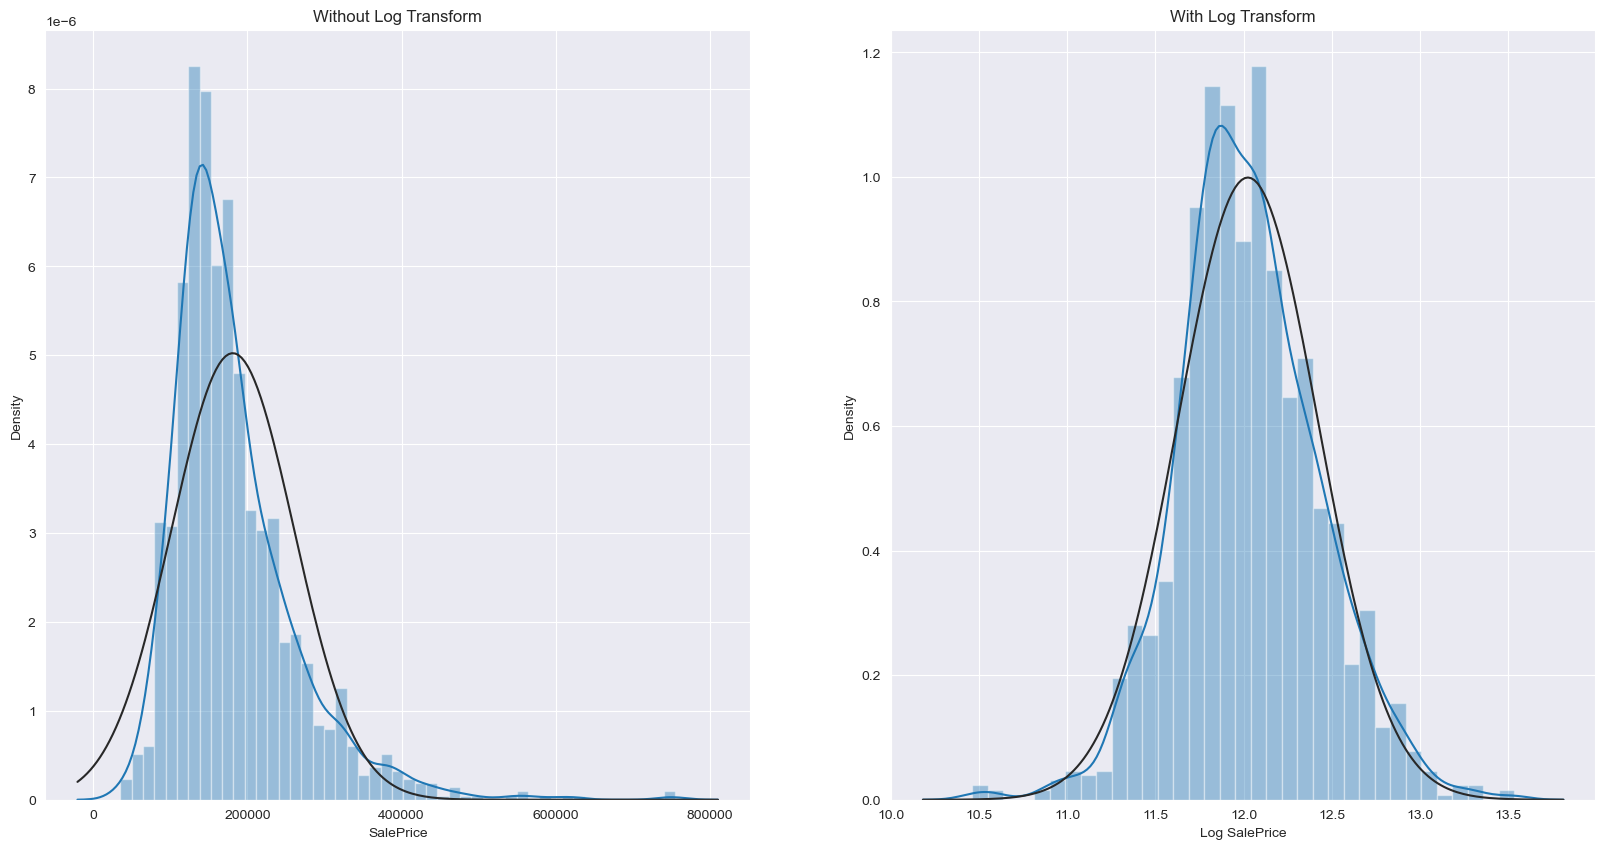

In [52]:
plt.figure(figsize=(20,10))

plt.subplot(1, 2, 1)
sns.distplot(target, kde=True, fit=scipy.stats.norm)
plt.title("Without Log Transform")

plt.subplot(1, 2, 2)
sns.distplot(np.log(target), kde=True, fit=scipy.stats.norm)
plt.xlabel("Log SalePrice")
plt.title("With Log Transform")

plt.show()
           

In [53]:
log_target = np.log(target)

In [54]:
# log_target

In [55]:
# for return the orginal target values

# np.exp(log_target)

# Split Data

In [56]:
train_final = data7.loc[:train0.index.max(), :].copy()
test_final = data7.loc[train0.index.max() + 1:, :].reset_index(drop=True).copy()

In [58]:
x_train = train_final.values
y_train = log_target.values

x_test = test_final.values
y_test = sample_submission['SalePrice'].values
y_test = np.log(y_test)
x_features = ['LotFrontage', 'LotArea', 'OverallQual', 'OverallCond', 'YearBuilt',
       'YearRemodAdd', 'MasVnrArea', 'BsmtFinSF1']

# Model selection

### 1- LinearRegression Model ----------------------------------------------------------------------------------------------------------------------

In [59]:
# Building a class for Linear Regression using Gradinent Descent

class LinearRegression:
    
    # assign values for hyper-parameters (learning rate and number of iterations)
    
    def __init__(self, L_rate=0.01, iterations=1000):
        self.L_rate = L_rate
        self.iterations = iterations
    
    # Fit the training data using Gradinent Descent
    
    def fit(self, x, y):
        self.cost = []                                                    # loss values.
        self.theta = np.zeros((1 + x.shape[1]))                           # initialization.
#       self.theta = np.random.randint(1,1000,(1 + x.shape[1]))           # random initialization.
        m = x.shape[0]                                                    # number of training examples. 
    
        for i in range(self.iterations):
            y_pred = self.theta[0] + np.dot(x, self.theta[1:])            # hypothesis f_wb(x)
            mse = (1/m) * np.sum((y_pred - y)**2)                         # compute the cost function J(w)
            self.cost.append(mse)
            
            #Derivatives
            d_theta1 = (2/m) * np.dot(x.T, (y_pred - y))                  # x.T=(3,40).... transpose x
            d_theta0 = (2/m) * np.sum(y_pred - y)
            
            #Values update
            self.theta[1:] = self.theta[1:] - self.L_rate * d_theta1      # W1, w2, w3
            self.theta[0] = self.theta[0] - self.L_rate * d_theta0        # w0 = b
        return self   

    # Predicts the values after the model has been trained using Gradinent Descent
    
    def predict(self, x):
        return self.theta[0] + np.dot(x, self.theta[1:])



### Fitting (Tuning alpha and number of iterations) 

In [60]:
# Training Steps:

# 1-Define values of Learning Rate & number of iterations.
Learning_rate = .045
Iterations = 200

# 2- Creat an object using the LinearRegression() class & calling the method that fit the training data { fit_GD()}
Lr = LinearRegression(Learning_rate,Iterations)
Lr.fit(x_train, y_train)

In [61]:
# Lr.theta

### predictions

In [62]:
final_predictions = Lr.predict(x_test)

submission = pd.concat([test_ids, pd.Series(np.exp(final_predictions), name='SalePrice')], axis=1 )

In [63]:
submission.to_csv('./LR-submission.csv', index=False, header=True)

### Evaluation

In [64]:
def adjustedR_square(x, y, y_pre): 
    SS_reg = np.sum((y_pre - y)**2)
    SS_tot = np.sum((y - np.mean(y))**2)
    RSE = 1 - (SS_reg/SS_tot)
    adjusted_RSE = 1 - ((1 - RSE) * (x.shape[0] - 1) / (x.shape[0] - x.shape[1] - 1))
 
    return adjusted_RSE

In [65]:
# Compute Root Mean Square Error

mse = (1/x_test.shape[0]) * np.sum((final_predictions - y_test)**2)
rmse = np.sqrt(mse)
print ("RMSE = ", rmse)

#Evaluate Training Gradinent Descent Model using adjusted R squared using testing dataset
adjusted_R2 = adjustedR_square(x_test, y_test, final_predictions)
print(f"Model Accuracy = %{adjusted_R2*100:0.2f}")

RMSE =  0.37651762715464226
Model Accuracy = %-4.52


### Learning curve

Initial loss = 144.74
Final loss = 0.01


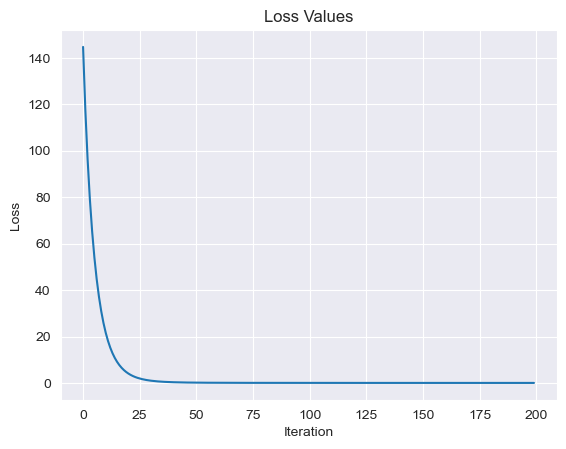

In [66]:
# Learning curve
plt.title('Loss Values')
plt.plot(Lr.cost)
plt.ylabel('Loss')
plt.xlabel('Iteration')
print(f"Initial loss = {Lr.cost[0]:0.2f}")
print(f"Final loss = {Lr.cost[-1]:0.2f}")


### Plotting (Target vs Predicted)

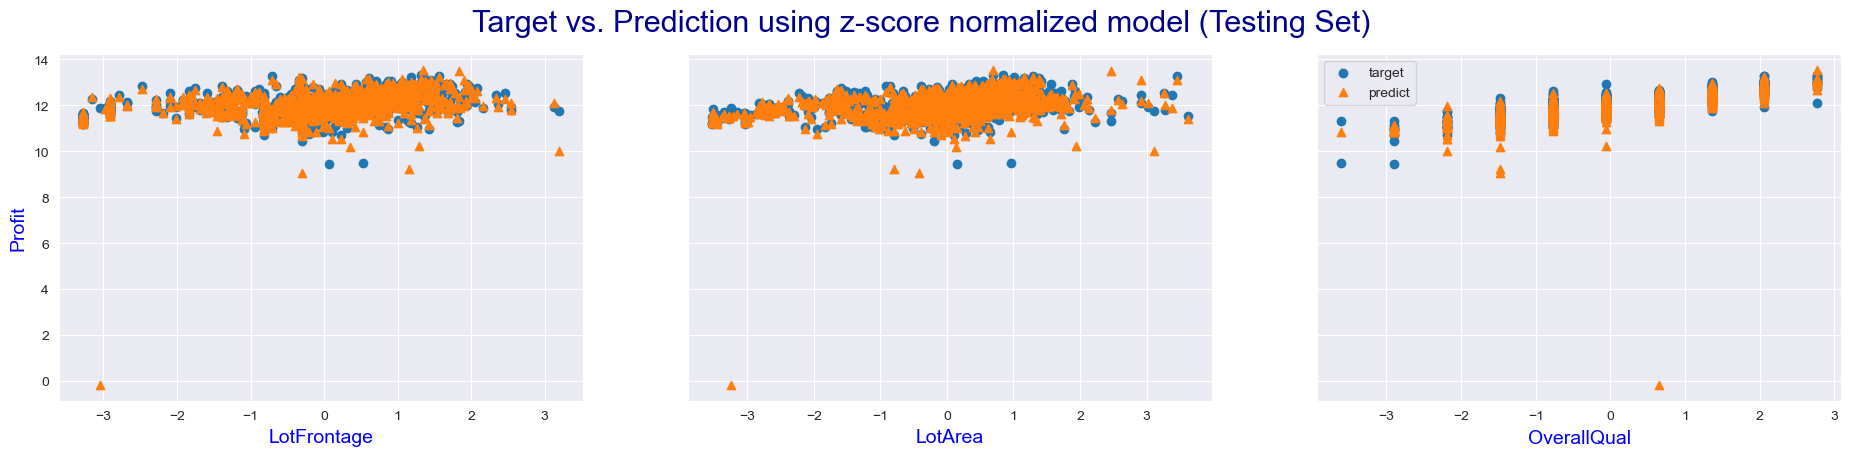

RMSE =  0.37651762715464226


In [67]:
# Ploting "Distribution features vs Profit" for testing dataset
fig, ax = plt.subplots(1,3, figsize = (23,4.5), sharey=True)
for i in range(len(ax)):
    ax[i].scatter(x_test[:,i], y_test , label='target')
    ax[i].set_xlabel(x_features[i], c='b',fontsize=14)
    ax[i].scatter(x_test[:,i],final_predictions, label='predict', marker='^')
ax[0].set_ylabel("Profit", c='b', fontsize=14)
fig.suptitle("Target vs. Prediction using z-score normalized model (Testing Set)", c='darkblue', fontsize=22)
plt.legend(loc="upper left")
plt.show()
print ("RMSE = ", rmse)

### 2-  polynomial Model ----------------------------------------------------------------------------------------------------------------------

In [68]:
# Building a class for Poly Linear Regression using Gradinent Descent

class Poly_LinearRegression:
    
    # assign values for hyper-parameters (learning rate and number of iterations)
    
    def __init__(self, L_rate=0.01, iterations=100, degree=2):
        self.L_rate = L_rate
        self.iterations = iterations
        self.degree = degree
    
    # Transform data to polynomial features
    
    def transformer(self, x):
        self.m = x.shape[0]
        x_transformed = np.empty((self.m, 0))                              # Empty 2D array
        
        for j in range(self.degree + 1):
            if j != 0:
                x_power = np.power(x, j)
                x_transformed = np.append(x_transformed, x_power, axis=1)
        return x_transformed        
        
    # Fit the training data using Gradinent Descent
    
    def fit(self, x, y):
        self.cost = []                                                    # loss values.
        x_p = self.transformer(x)
        self.theta = np.zeros((1 + x_p.shape[1]))                           # initialization.
#       self.theta = np.random.randint(1,1000,(1 + x.shape[1]))           # random initialization.
       
        
        for i in range(self.iterations):
            
            y_pred = self.theta[0] + np.dot(x_p, self.theta[1:])            # hypothesis f_wb(x)
            mse = (1/self.m) * np.sum((y_pred - y)**2)                         # compute the cost function J(w)
            self.cost.append(mse)
            
            #Derivatives
            d_theta1 = (2/self.m) * np.dot(x_p.T, (y_pred - y))                  # x.T=(3,40).... transpose x
            d_theta0 = (2/self.m) * np.sum(y_pred - y)
            
            #Values update
            self.theta[1:] = self.theta[1:] - self.L_rate * d_theta1      # W1, w2, w3
            self.theta[0] = self.theta[0] - self.L_rate * d_theta0        # w0 = b
        return self   

    # Predicts the values after the model has been trained using Gradinent Descent
    
    def predict(self, x):
        
        x_p = self.transformer(x)
        return self.theta[0] + np.dot(x_p, self.theta[1:])



### Fitting (Tuning alpha and number of iterations) 

In [69]:
Learning_rate = 0.00008
Iterations = 40000
degree=2

plr = Poly_LinearRegression(Learning_rate, Iterations, degree)
plr.fit(x_train, y_train)


In [70]:
# plr.theta

### predictions

In [71]:
final_predictions = plr.predict(x_test)

submission = pd.concat([test_ids, pd.Series(np.exp(final_predictions), name='SalePrice')], axis=1 )

In [72]:
submission.to_csv('./Poly-submission.csv', index=False, header=True)

### Evaluation

In [73]:
# Compute Root Mean Square Error

mse = (1/x_test.shape[0]) * np.sum((final_predictions - y_test)**2)
rmse = np.sqrt(mse)
print ("RMSE = ", rmse)

# Evaluation#Evaluate Training Gradinent Descent Model using adjusted R squared using testing dataset
adjusted_R2 = adjustedR_square(x_test, y_test, final_predictions)
print(f"Model Accuracy = %{adjusted_R2*100:0.2f}")

RMSE =  0.2036854740987714
Model Accuracy = %69.41


### Learning curve

Initial loss = 144.74
Final loss = 0.01


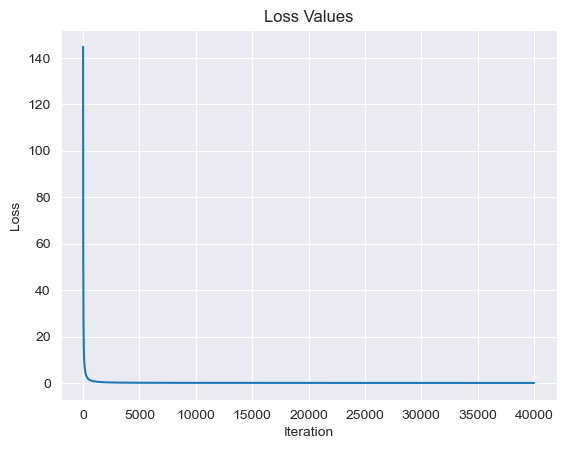

In [74]:
plt.title('Loss Values')
plt.plot(plr.cost)
plt.ylabel('Loss')
plt.xlabel('Iteration')
print(f"Initial loss = {plr.cost[0]:0.2f}")
print(f"Final loss = {plr.cost[-1]:0.2f}")


### Plotting (Target vs Predicted)

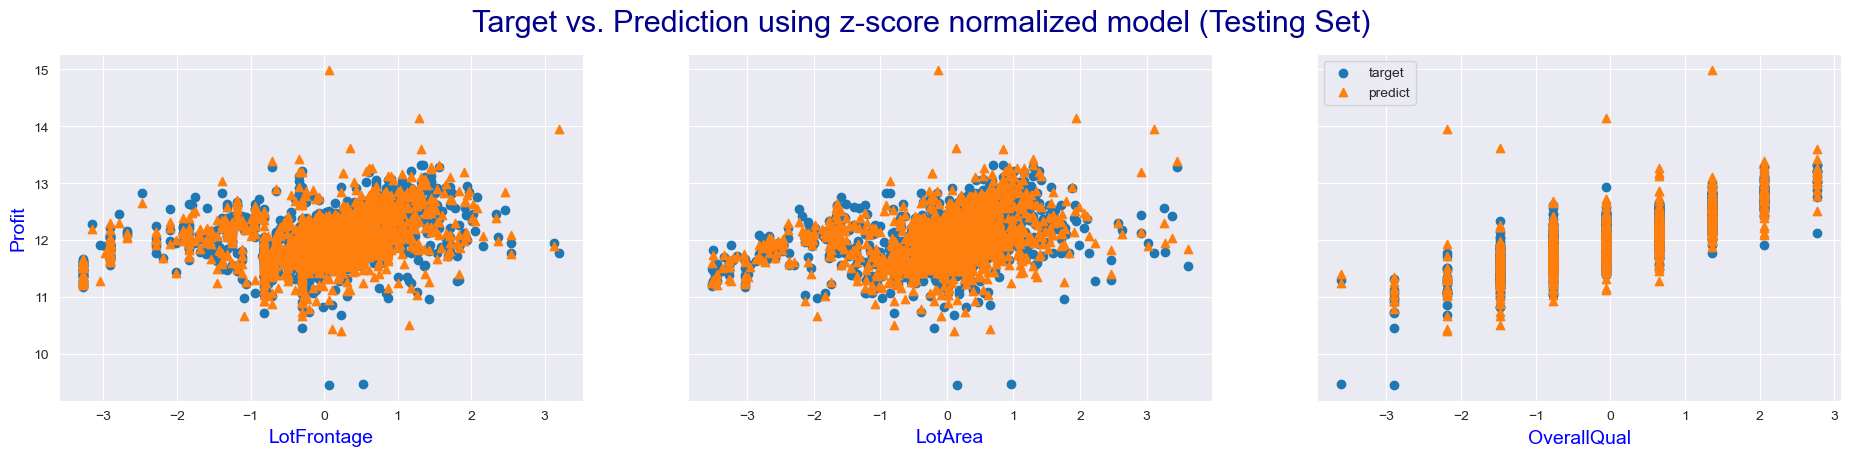

RMSE =  0.2036854740987714


In [75]:
# Ploting "Distribution features vs Profit" for testing dataset
fig, ax = plt.subplots(1,3, figsize = (23,4.5), sharey=True)
for i in range(len(ax)):
    ax[i].scatter(x_test[:,i], y_test , label='target')
    ax[i].set_xlabel(x_features[i], c='b',fontsize=14)
    ax[i].scatter(x_test[:,i],final_predictions, label='predict', marker='^')

ax[0].set_ylabel("Profit", c='b', fontsize=14)
fig.suptitle("Target vs. Prediction using z-score normalized model (Testing Set)", c='darkblue', fontsize=22)
plt.legend(loc="upper left")
plt.show()
print ("RMSE = ", rmse)

### 3- Ridge Model (L2).----------------------------------------------------------------------------------------------------------------------

In [76]:
class Ridge:
    
    # assign values for hyper-parameters (learning rate and number of iterations)
    
    def __init__(self, L_rate=0.001, iterations=10000, degree=3, lambda_value=0.01):
        self.L_rate = L_rate
        self.iterations = iterations
        self.degree = degree
        self.lambda_value = lambda_value
        
        # Z-score Scaling Methode
        
    def scale(self, x):
        x_scaled = x-np.mean(x, axis=0)
        x_scaled = x_scaled / np.std(x_scaled, axis=0)
        return x_scaled    
    
    # Transform data to polynomial features
    
    def transformer(self, x):
        
        self.m = x.shape[0]
        x_transformed = np.empty((self.m, 0))                              # Empty 2D array
        
        for j in range(self.degree + 1):
            if j != 0:
                x_power = np.power(x, j)
                x_transformed = np.append(x_transformed, x_power, axis=1)
        return x_transformed        
        
    # Fit the training data using Gradinent Descent
    
    def fit(self, x, y):
        self.cost = []                                                    # loss values.
        
        x_p = self.transformer(x)
        self.theta = np.zeros((1 + x_p.shape[1]))                           # initialization.
#       self.theta = np.random.randint(1,1000,(1 + x.shape[1]))           # random initialization.
       
        
        for i in range(self.iterations):
            
            y_pred = self.theta[0] + np.dot(x_p, self.theta[1:])            # hypothesis f_wb(x)
            L2 = self.lambda_value * np.sum(np.square(self.theta[1:]))
            mse = (1/self.m) * np.sum((y_pred - y)**2) + L2                  # compute the cost function J(w)
            self.cost.append(mse)
            
            #Derivatives
            d_theta1 = (2/self.m) * np.dot(x_p.T, (y_pred - y)) - L2                 # x.T=(3,40).... transpose x
            d_theta0 = (2/self.m) * np.sum(y_pred - y)
            
            #Values update
            self.theta[1:] = self.theta[1:] - self.L_rate * d_theta1      # W1, w2, w3
            self.theta[0] = self.theta[0] - self.L_rate * d_theta0        # w0 = b
        return self   

    # Predicts the values after the model has been trained using Gradinent Descent
    
    def predict(self, x):
        
    
        x_p = self.transformer(x)
        return self.theta[0] + np.dot(x_p, self.theta[1:])

### Fitting (Tuning alpha and number of iterations) 

In [77]:
Learning_rate = 0.00008
Iterations = 40000
degree=2
lambda_value = 0.00001

L2_ridge = Ridge(Learning_rate, Iterations, degree, lambda_value)
L2_ridge.fit(x_train, y_train)

In [78]:
# L2_ridge.theta

### predictions

In [79]:
final_predictions = L2_ridge.predict(x_test)

submission = pd.concat([test_ids, pd.Series(np.exp(final_predictions), name='SalePrice')], axis=1 )

In [80]:
submission.to_csv('./Ridge-L2-submission.csv', index=False, header=True)

### Evaluation

In [81]:
# Compute Root Mean Square Error

mse = (1/x_test.shape[0]) * np.sum((final_predictions - y_test)**2)
rmse = np.sqrt(mse)
print ("RMSE = ", rmse)

#Evaluate Training Gradinent Descent Model using adjusted R squared using testing dataset
adjusted_R2 = adjustedR_square(x_test, y_test, final_predictions)
print(f"Model Accuracy = %{adjusted_R2*100:0.2f}")

RMSE =  0.20335613162665495
Model Accuracy = %69.51


### Learning curve

Initial loss = 144.74
Final loss = 0.01


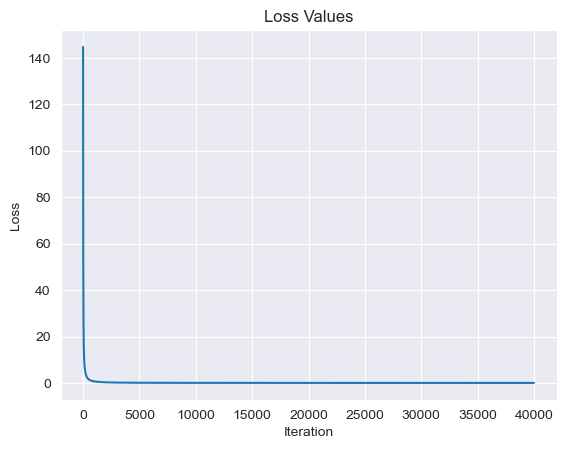

In [82]:
# Learning curve
plt.title('Loss Values')
plt.plot(L2_ridge.cost)
plt.ylabel('Loss')
plt.xlabel('Iteration')
print(f"Initial loss = {L2_ridge.cost[0]:0.2f}")
print(f"Final loss = {L2_ridge.cost[-1]:0.2f}")


### Plotting (Target vs Predicted)

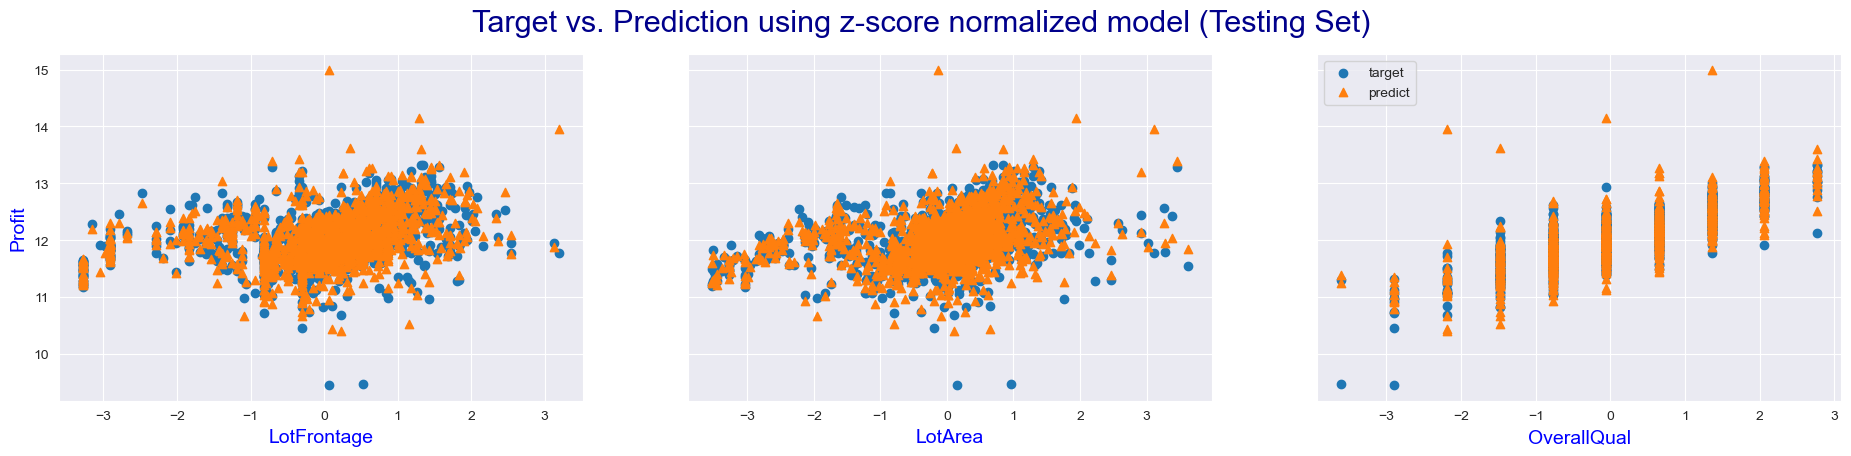

RMSE =  0.20335613162665495


In [83]:
# Ploting "Distribution features vs Profit" for testing dataset
fig, ax = plt.subplots(1,3, figsize = (23,4.5), sharey=True)
for i in range(len(ax)):
    ax[i].scatter(x_test[:,i], y_test , label='target')
    ax[i].set_xlabel(x_features[i], c='b',fontsize=14)
    ax[i].scatter(x_test[:,i],final_predictions, label='predict', marker='^')

ax[0].set_ylabel("Profit", c='b', fontsize=14)
fig.suptitle("Target vs. Prediction using z-score normalized model (Testing Set)", c='darkblue', fontsize=22)
plt.legend(loc="upper left")
plt.show()
print ("RMSE = ", rmse)

### 4- Lasso Model (L1).----------------------------------------------------------------------------------------------------------------------

In [84]:
class Lasso:
    
    # assign values for hyper-parameters (learning rate and number of iterations)
    
    def __init__(self, L_rate=0.001, iterations=10000, degree=2, lambda_value=0.01):
        self.L_rate = L_rate
        self.iterations = iterations
        self.degree = degree
        self.lambda_value = lambda_value
       
    # Z-score Scaling Methode
        
#     def scale(self, x):
#         x_scaled = x-np.mean(x, axis=0)
#         x_scaled = x_scaled / np.std(x_scaled, axis=0)
#         return x_scaled    
    
    # Transform data to polynomial features
    
    def transformer(self, x):
        
        self.m = x.shape[0]
        x_transformed = np.empty((self.m, 0))                              # Empty 2D array
        
        for j in range(self.degree + 1):
            if j != 0:
                x_power = np.power(x, j)
                x_transformed = np.append(x_transformed, x_power, axis=1)
        return x_transformed        
        
    # Fit the training data using Gradinent Descent
    
    def fit(self, x, y):
        self.cost = []                                                             # loss values.
        x_p = self.transformer(x)
        self.theta = np.zeros((1 + x_p.shape[1]))                                   # initialization.
#       self.theta = np.random.randint(1,1000,(1 + x.shape[1]))                     # random initialization.
       
        
        for i in range(self.iterations):
            
            y_pred = self.theta[0] + np.dot(x_p, self.theta[1:])                     # hypothesis f_wb(x)
            L2 = self.lambda_value * np.sum(np.abs(self.theta[1:]))
            mse = (1/self.m) * np.sum((y_pred - y)**2) + L2                          # compute the cost function J(w)
            self.cost.append(mse)
            
            #Derivatives
            d_theta1 = (2/self.m) * np.dot(x_p.T, (y_pred - y)) - L2                 # x.T=(3,40).... transpose x
            d_theta0 = (2/self.m) * np.sum(y_pred - y)
            
            #Values update
            self.theta[1:] = self.theta[1:] - self.L_rate * d_theta1                 # W1, w2, w3, ....
            self.theta[0] = self.theta[0] - self.L_rate * d_theta0                   # w0 = b
        return self   

    # Predicts the values after the model has been trained using Gradinent Descent
    
    def predict(self, x):
        
        x_p = self.transformer(x)
        return self.theta[0] + np.dot(x_p, self.theta[1:])
    

### Fitting (Tuning alpha and number of iterations) 

In [85]:
Learning_rate = 0.00008
Iterations = 40000
degree=2
lambda_value = 0.000001

L1_Lasso = Lasso(Learning_rate, Iterations, degree, lambda_value)
L1_Lasso.fit(x_train, y_train)

In [86]:
# L1_Lasso.theta

### predictions

In [87]:
final_predictions = L1_Lasso.predict(x_test)

submission = pd.concat([test_ids, pd.Series(np.exp(final_predictions), name='SalePrice')], axis=1 )

In [88]:
submission.to_csv('./Lasso-L1-submission.csv', index=False, header=True)

### Evaluation

In [89]:
# Compute Root Mean Square Error

mse = (1/x_test.shape[0]) * np.sum((final_predictions - y_test)**2)
rmse = np.sqrt(mse)
print ("RMSE = ", rmse)

#Evaluate Training Gradinent Descent Model using adjusted R squared using testing dataset
adjusted_R2 = adjustedR_square(x_test, y_test, final_predictions)
print(f"Model Accuracy = %{adjusted_R2*100:0.2f}")

RMSE =  0.20332465962282295
Model Accuracy = %69.52


### Learning curve

Initial loss = 144.74
Final loss = 0.01


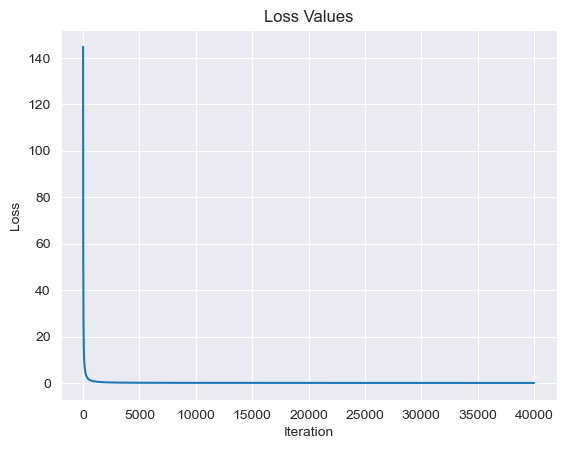

In [90]:
# Learning curve
plt.title('Loss Values')
plt.plot(L1_Lasso.cost)
plt.ylabel('Loss')
plt.xlabel('Iteration')
print(f"Initial loss = {L1_Lasso.cost[0]:0.2f}")
print(f"Final loss = {L1_Lasso.cost[-1]:0.2f}")

### Plotting (Target vs Predicted)

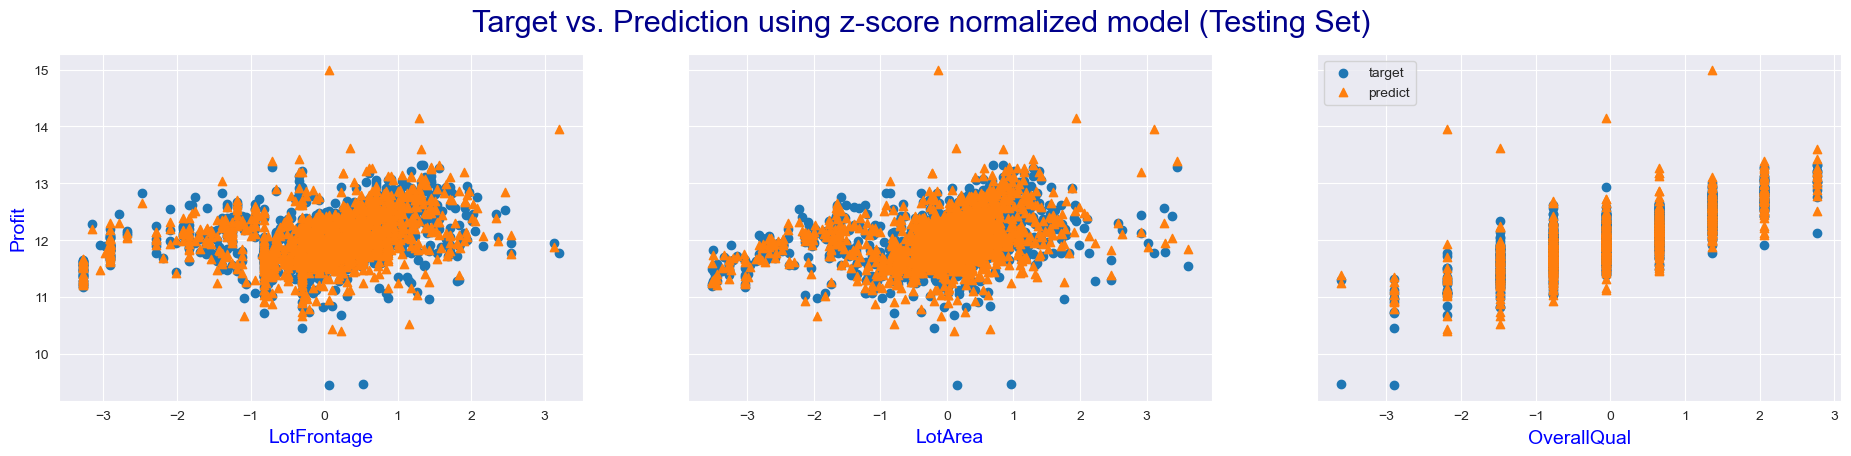

RMSE =  0.20332465962282295


In [91]:
# Ploting "Distribution features vs Profit" for testing dataset
fig, ax = plt.subplots(1,3, figsize = (23,4.5), sharey=True)
for i in range(len(ax)):
    ax[i].scatter(x_test[:,i], y_test , label='target')
    ax[i].set_xlabel(x_features[i], c='b',fontsize=14)
    ax[i].scatter(x_test[:,i],final_predictions, label='predict', marker='^')

ax[0].set_ylabel("Profit", c='b', fontsize=14)
fig.suptitle("Target vs. Prediction using z-score normalized model (Testing Set)", c='darkblue', fontsize=22)
plt.legend(loc="upper left")
plt.show()
print ("RMSE = ", rmse)

### 5-sklearn.linear_model.LinearRegression --------------------------------------------------------------------------------------------------

In [92]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

### Fitting 

In [93]:
sKlearn_Lr = LinearRegression()
sKlearn_Lr.fit(x_train, y_train)

LinearRegression()

### predictions

In [94]:
final_predictions = sKlearn_Lr.predict(x_test)

submission = pd.concat([test_ids, pd.Series(np.exp(final_predictions), name='SalePrice')], axis=1 )

C:\Users\Hp\AppData\Local\Temp\ipykernel_20188\1923767713.py:3: RuntimeWarning: overflow encountered in exp
  submission = pd.concat([test_ids, pd.Series(np.exp(final_predictions), name='SalePrice')], axis=1 )


In [95]:
submission.to_csv('./sKlearn_Lr-submission.csv', index=False, header=True)

### Evaluation

In [121]:
# Compute Root Mean Square Error

mse = (1/x_test.shape[0]) * np.sum((final_predictions - y_test)**2)
rmse = np.sqrt(mse)
print ("RMSE = ", rmse)

# The coefficients
# print("Coefficients: \n", sKlearn_Lr.coef_)
# The mean squared error
print("Mean squared error: %.2f" % mean_squared_error(y_test, final_predictions))
# The coefficient of determination: 1 is perfect prediction
print("Model Accuracy: %.2f" % r2_score(y_test, final_predictions))

RMSE =  0.22851123042391755
Mean squared error: 0.05
Model Accuracy: 0.70


### 6- sklearn.preprocessing.PolynomialFeatures¶------------------------------------------------------------------------------------------

### Fitting 

In [122]:
from sklearn.preprocessing import PolynomialFeatures
poly = PolynomialFeatures(degree = 2)
x_train_poly = poly.fit_transform(x_train)
x_test_poly = poly.fit_transform(x_test)

In [123]:
sKlearn_Lr = LinearRegression()
sKlearn_Lr.fit(x_train_poly, y_train)

LinearRegression()

### predictions

In [124]:
final_predictions = sKlearn_Lr.predict(x_test_poly)

submission = pd.concat([test_ids, pd.Series(np.exp(final_predictions), name='SalePrice')], axis=1 )

In [125]:
submission.to_csv('./sKlearn_poly-submission.csv', index=False, header=True)

### Evaluation

In [126]:
# Compute Root Mean Square Error

mse = (1/x_test_poly.shape[0]) * np.sum((final_predictions - y_test)**2)
rmse = np.sqrt(mse)
print ("RMSE = ", rmse)

# The coefficients
# print("Coefficients: \n", sKlearn_Lr.coef_)
# The mean squared error
print("Mean squared error: %.2f" % mean_squared_error(y_test, final_predictions))
# The coefficient of determination: 1 is perfect prediction
print("Model Accuracy: %.2f" % r2_score(y_test, final_predictions))

RMSE =  0.22851123042391755
Mean squared error: 0.05
Model Accuracy: 0.70


### Plotting (Target vs Predicted)

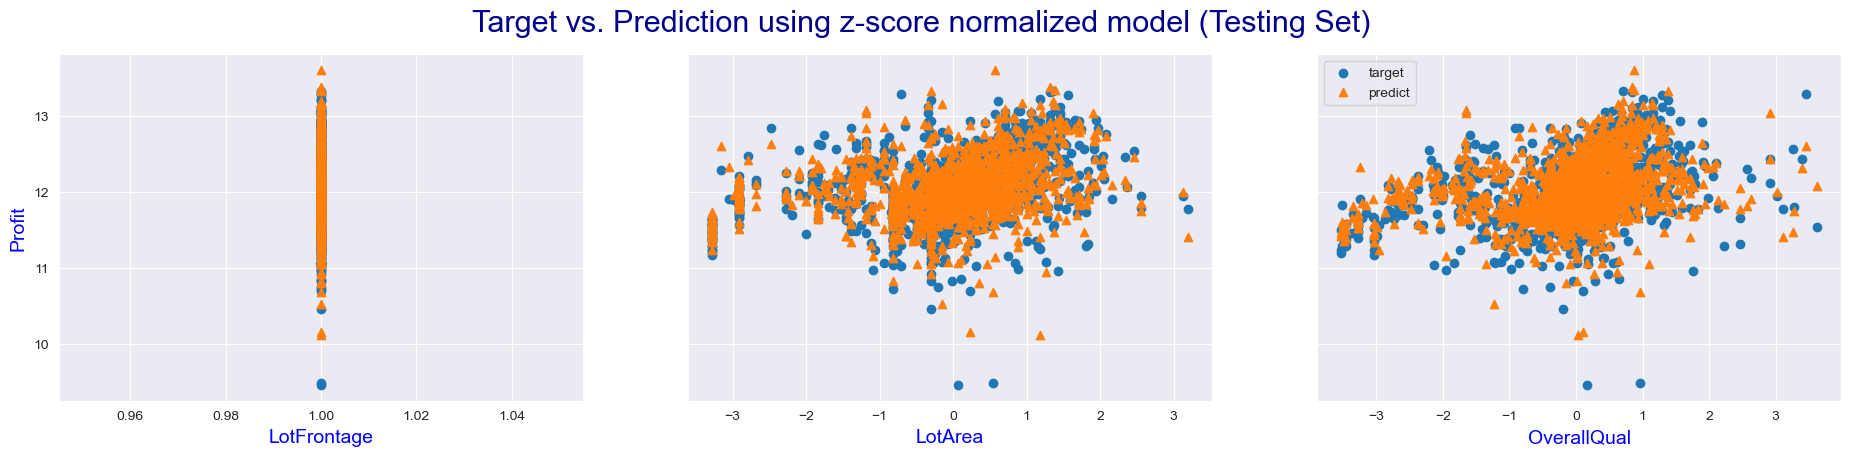

RMSE =  0.22851123042391755


In [127]:
# Ploting "Distribution features vs Profit" for testing dataset
fig, ax = plt.subplots(1,3, figsize = (23,4.5), sharey=True)
for i in range(len(ax)):
    ax[i].scatter(x_test_poly[:,i], y_test , label='target')
    ax[i].set_xlabel(x_features[i], c='b',fontsize=14)
    ax[i].scatter(x_test_poly[:,i],final_predictions, label='predict', marker='^')

ax[0].set_ylabel("Profit", c='b', fontsize=14)
fig.suptitle("Target vs. Prediction using z-score normalized model (Testing Set)", c='darkblue', fontsize=22)
plt.legend(loc="upper left")
plt.show()
print ("RMSE = ", rmse)

### 7- sklearn.linear_model.Ridge -----------------------------------------------------------------------------------------------------------------


In [102]:
from sklearn.linear_model import Ridge

### Fitting 

In [128]:
sKlearn_Ridge = Ridge(alpha=10)
sKlearn_Ridge.fit(x_train, y_train)

Ridge(alpha=10)

### predictions

In [129]:
final_predictions = sKlearn_Ridge.predict(x_test)

submission = pd.concat([test_ids, pd.Series(np.exp(final_predictions), name='SalePrice')], axis=1 )
submission

,Id,SalePrice
0,1461,121814.012304
1,1462,167741.851902
2,1463,186808.616522
3,1464,202859.688341
4,1465,197716.974402
...,...,...
1454,2915,83979.593565
1455,2916,80128.107460
1456,2917,173353.335595
1457,2918,121117.123692


In [130]:
submission.to_csv('./sKlearn_Ridge-submission.csv', index=False, header=True)

### Evaluation

In [131]:
# Compute Root Mean Square Error

mse = (1/x_test.shape[0]) * np.sum((final_predictions - y_test)**2)
rmse = np.sqrt(mse)
print ("RMSE = ", rmse)

# The coefficients
# print("Coefficients: \n", sKlearn_Ridge.coef_)
# The mean squared error
print("Mean squared error: %.2f" % mean_squared_error(y_test, final_predictions))
# The coefficient of determination: 1 is perfect prediction
print("R-square score: %.2f" % r2_score(y_test, final_predictions))

RMSE =  0.138356420119048
Mean squared error: 0.02
R-square score: 0.89


### Plotting (Target vs Predicted)

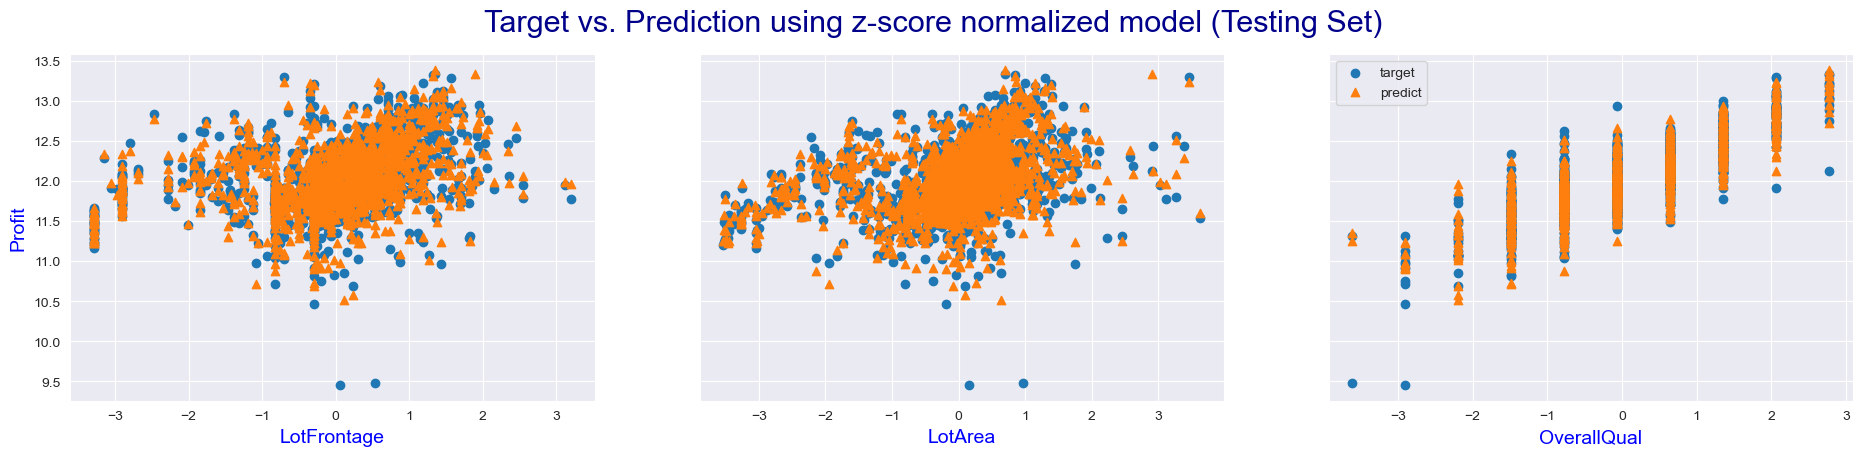

RMSE =  0.138356420119048


In [107]:
# Ploting "Distribution features vs Profit" for testing dataset
fig, ax = plt.subplots(1,3, figsize = (23,4.5), sharey=True)
for i in range(len(ax)):
    ax[i].scatter(x_test[:,i], y_test , label='target')
    ax[i].set_xlabel(x_features[i], c='b',fontsize=14)
    ax[i].scatter(x_test[:,i],final_predictions, label='predict', marker='^')

ax[0].set_ylabel("Profit", c='b', fontsize=14)
fig.suptitle("Target vs. Prediction using z-score normalized model (Testing Set)", c='darkblue', fontsize=22)
plt.legend(loc="upper left")
plt.show()
print ("RMSE = ", rmse)

### 8- sklearn.linear_model.Lasso ----------------------------------------------------------------------------------------------------------------


In [132]:
from sklearn.linear_model import Lasso

### Fitting 

In [133]:
sKlearn_Lasso = Lasso(alpha=0.005, tol=0.003)
sKlearn_Lasso.fit(x_train, y_train)

Lasso(alpha=0.005, tol=0.003)

### predictions

In [134]:
final_predictions = sKlearn_Lasso.predict(x_test)

submission = pd.concat([test_ids, pd.Series(np.exp(final_predictions), name='SalePrice')], axis=1 )
submission

,Id,SalePrice
0,1461,122572.188586
1,1462,154598.161001
2,1463,179174.653797
3,1464,195594.972724
4,1465,201850.293695
...,...,...
1454,2915,89981.276145
1455,2916,88205.868971
1456,2917,165376.324671
1457,2918,123035.451454


In [138]:
submission.to_csv('./sKlearn_Lasso-submission.csv', index=False, header=True)

In [142]:
# Differente between actual and predicted values for testing dataset
pred_y_df = pd.DataFrame({'Actual Value':np.exp(y_test), 'Predicted Value':np.exp(final_predictions), 'Difference':np.exp(y_test) - np.exp(final_predictions), ' Percentage (%)':(np.exp(final_predictions)*100/np.exp(y_test))})
pred_y_df

,Actual Value,Predicted Value,Difference,Percentage (%)
0,105000.0,122572.188586,-17572.188586,116.735418
1,172000.0,154598.161001,17401.838999,89.882652
2,189900.0,179174.653797,10725.346203,94.352108
3,195500.0,195594.972724,-94.972724,100.048579
4,191500.0,201850.293695,-10350.293695,105.404853
...,...,...,...,...
1454,90500.0,89981.276145,518.723855,99.426824
1455,71000.0,88205.868971,-17205.868971,124.233618
1456,131000.0,165376.324671,-34376.324671,126.241469
1457,132000.0,123035.451454,8964.548546,93.208675


### Evaluation

In [136]:
# Compute Root Mean Square Error

mse = (1/x_test.shape[0]) * np.sum((final_predictions - y_test)**2)
rmse = np.sqrt(mse)
print ("RMSE = ", rmse)

# The coefficients
# print("Coefficients: \n", sKlearn_Lasso.coef_)
# The mean squared error
print("Mean squared error: %.2f" % mean_squared_error(y_test, final_predictions))
# The coefficient of determination: 1 is perfect prediction
print("R-square score: %.2f" % r2_score(y_test, final_predictions))

RMSE =  0.1276345535324261
Mean squared error: 0.02
R-square score: 0.91


### Plotting (Target vs Predicted)

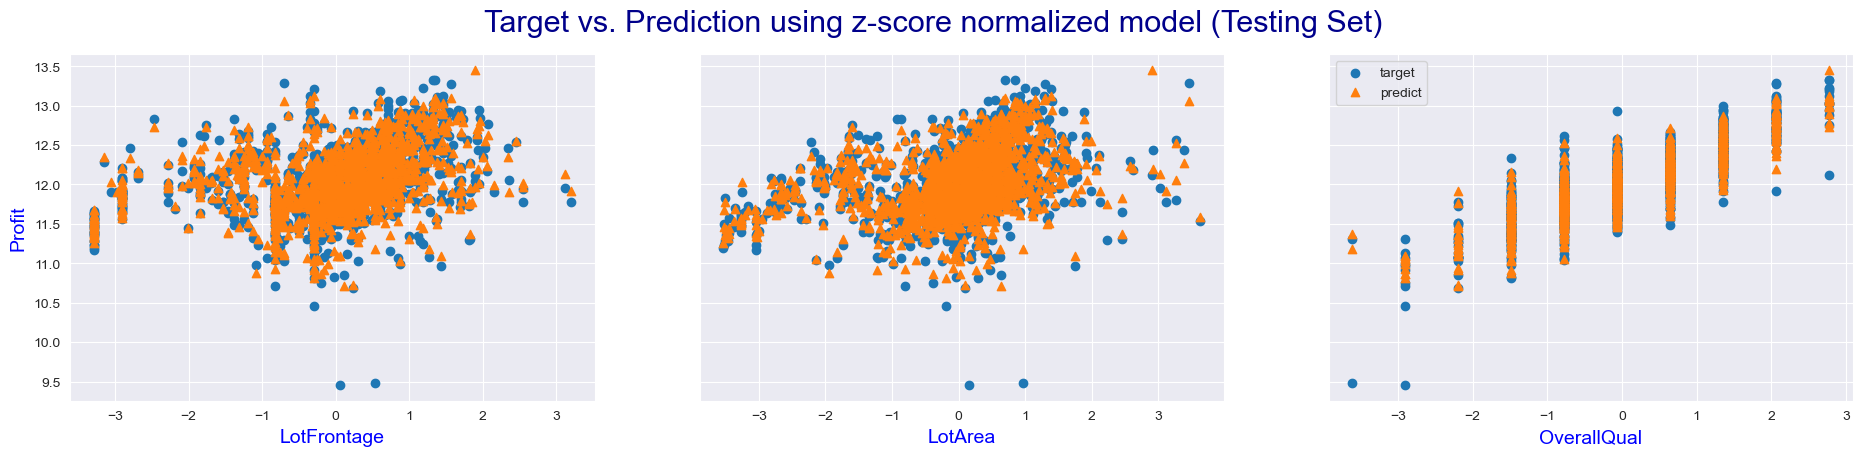

RMSE =  0.1276345535324261


In [113]:
# Ploting "Distribution features vs Profit" for testing dataset
fig, ax = plt.subplots(1,3, figsize = (23,4.5), sharey=True)
for i in range(len(ax)):
    ax[i].scatter(x_test[:,i], y_test , label='target')
    ax[i].set_xlabel(x_features[i], c='b',fontsize=14)
    ax[i].scatter(x_test[:,i],final_predictions, label='predict', marker='^')

ax[0].set_ylabel("Profit", c='b', fontsize=14)
fig.suptitle("Target vs. Prediction using z-score normalized model (Testing Set)", c='darkblue', fontsize=22)
plt.legend(loc="upper left")
plt.show()
print ("RMSE = ", rmse)